# Train Commutative CNN

This notebook intentionally keeps orchestration thin. Split preparation, fitting, reporting, plotting, and persistence are delegated to shared utilities in `src.ml`.


In [23]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_holdout_branch_embedding_projections,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from src.ml import CommutativeCNNClassifier, CommutativeCNNConfig


In [25]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
print(dataset_artifact_path.name)
experiment_output_dir = Path("artifacts/nb7_commutative_cnn")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeCNNConfig(
    spatial_conv_channels=(8, 12, 16),
    spatial_kernel_size_z=(1, 1, 1),
    spatial_kernel_size_xy=(5, 3, 3),
    spatial_stride_z=(1, 1, 1),
    spatial_stride_xy=(1, 1, 1),
    spatial_pool_kernel_z=(1, 1, 1),
    spatial_pool_kernel_xy=(2, 2, 2),
    spatial_pool_stride_z=(1, 1, 1),
    spatial_pool_stride_xy=(2, 2, 2),
    temporal_st_channels=(24, 24),
    temporal_st_kernel_sizes=(3, 3),
    temporal_ts_channels=(16, 16),
    temporal_ts_kernel_sizes=(5, 5),
    spatial_agg_channels=(16, 32),
    spatial_agg_kernel_size_z=(3, 3),
    spatial_agg_kernel_size_xy=(3, 3),
    spatial_agg_stride_z=(1, 1),
    spatial_agg_stride_xy=(1, 1),
    spatial_agg_pool_kernel_z=(1, 1),
    spatial_agg_pool_kernel_xy=(2, 2),
    spatial_agg_pool_stride_z=(1, 1),
    spatial_agg_pool_stride_xy=(2, 2),
    patch_size_z=1,
    patch_size_xy=8,
    embedding_dim=16,
    num_prototypes=12,
    dropout=0.45,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=2e-4,
    weight_decay=3e-3,
    early_stopping_patience=4,
    early_stopping_min_delta=0.0,
    scheduler_patience=1,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.2,
    concentration_weight=0.2,
    consistency_weight=0.15,
    feature_weight=0.01,
    prototype_temperature=0.1,
)


moa_4class_c2_mca1_mtc8_t3_z1_y32_x32.pt


In [26]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)


In [27]:
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)


In [28]:
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,245
1,train_base,35
2,val,9
3,holdout,15


,mechanism_of_action,compound,concentration_band,n_samples
0,NMDAR_Activation,(RS)-(Tetrazol-5-yl)glycine,control,42
1,GABAAR_NegativeAllostericModulator,DMCM,control,35
2,NMDAR_Antagonist,Ketamine,high,35
3,GABAAR_Antagonist,Bemegride,high,28
4,GABAAR_NegativeAllostericModulator,DMCM,high,28
5,NMDAR_Activation,(RS)-(Tetrazol-5-yl)glycine,high,28
6,NMDAR_Antagonist,Ketamine,control,28
7,GABAAR_Antagonist,Bemegride,control,21


In [29]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
)


In [30]:
fit_estimator_on_experiment(model, experiment)


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 2.00e-04     31:46 |   3.3438   1.6923   7.9346   1.5023   1.5257   0.7057 |   2.5769   1.6563   3.1415   0.0777   1.5464   0.6965
002/100 2.00e-04     31:24 |   3.0582   1.6267   6.5163   1.1414   1.5196   0.6935 |   2.5538   1.6063   3.3326   0.1704   1.5463   0.6834
003/100 2.00e-04     31:05 |   2.8593   1.6046   5.3691   0.9643   1.5151   0.6834 |   2.4908   1.5568   3.2607   0.1875   1.5285   0.6867
004

,spatial_conv_channels,"(8, ...)"
,spatial_kernel_size_z,"(1, ...)"
,spatial_kernel_size_xy,"(5, ...)"
,spatial_stride_z,"(1, ...)"
,spatial_stride_xy,"(1, ...)"
,spatial_pool_kernel_z,"(1, ...)"
,spatial_pool_kernel_xy,"(2, ...)"
,spatial_pool_stride_z,"(1, ...)"
,spatial_pool_stride_xy,"(2, ...)"
,temporal_st_channels,"(24, ...)"
,temporal_st_kernel_sizes,"(3, ...)"


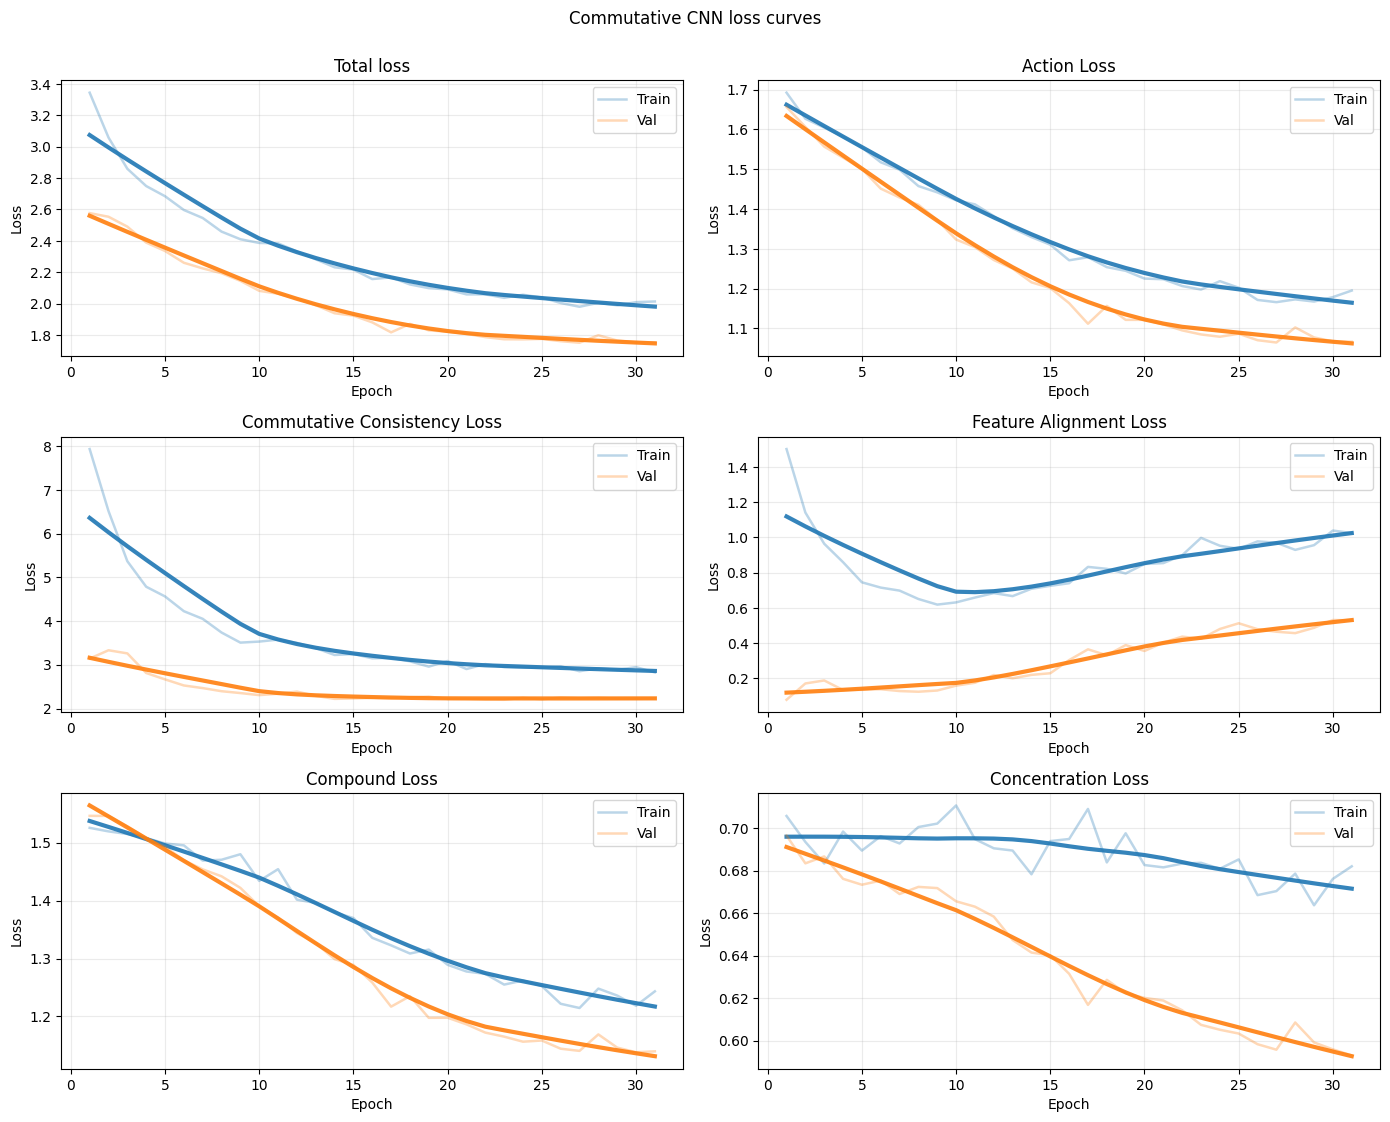

In [31]:
plot_training_history(model, title="Commutative CNN loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.538462,1.0,0.7,7.0
GABAAR_Antagonist,0.000000,0.0,0.0,2.0
GABAAR_NegativeAllostericModulator,0.000000,0.0,0.0,2.0
NMDAR_Activation,0.500000,0.5,0.5,2.0
NMDAR_Antagonist,0.000000,0.0,0.0,2.0


,value
accuracy,0.533333
macro_precision,0.207692
macro_recall,0.300000
macro_f1,0.240000
weighted_precision,0.317949
weighted_recall,0.533333
weighted_f1,0.393333
n_samples,15.000000
roc_auc_ovr_macro,0.668956
average_precision_macro,0.424023


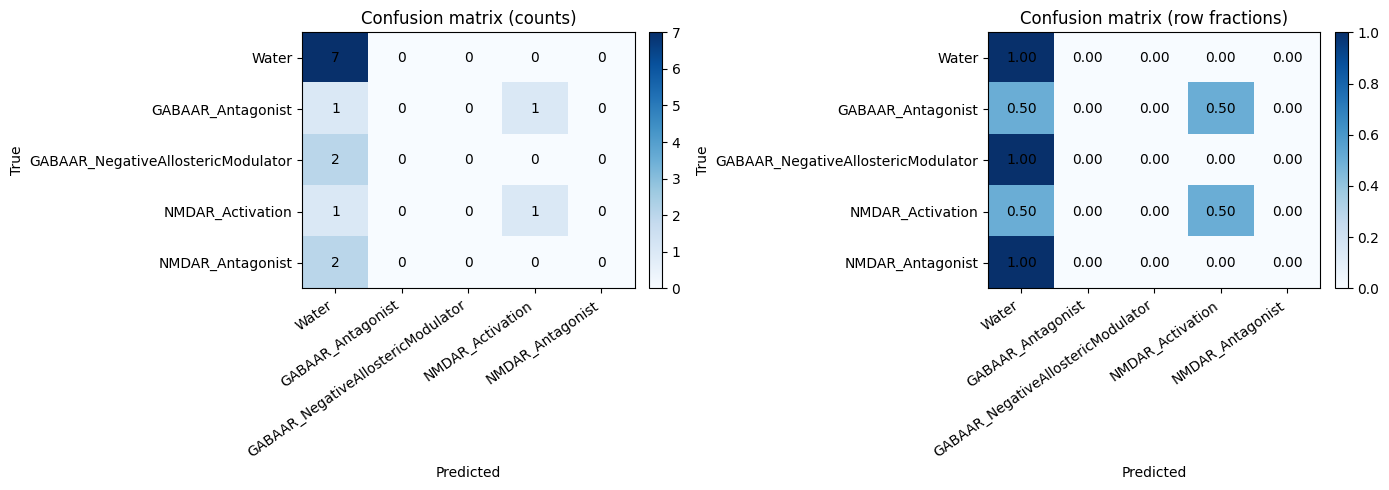


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.5,1.0,0.666667,7.0
Bemegride,0.0,0.0,0.000000,2.0
DMCM,0.0,0.0,0.000000,2.0
(RS)-(Tetrazol-5-yl)glycine,0.0,0.0,0.000000,2.0
Ketamine,0.0,0.0,0.000000,2.0


,value
accuracy,0.466667
macro_precision,0.100000
macro_recall,0.200000
macro_f1,0.133333
weighted_precision,0.233333
weighted_recall,0.466667
weighted_f1,0.311111
n_samples,15.000000
roc_auc_ovr_macro,0.603297
average_precision_macro,0.378622


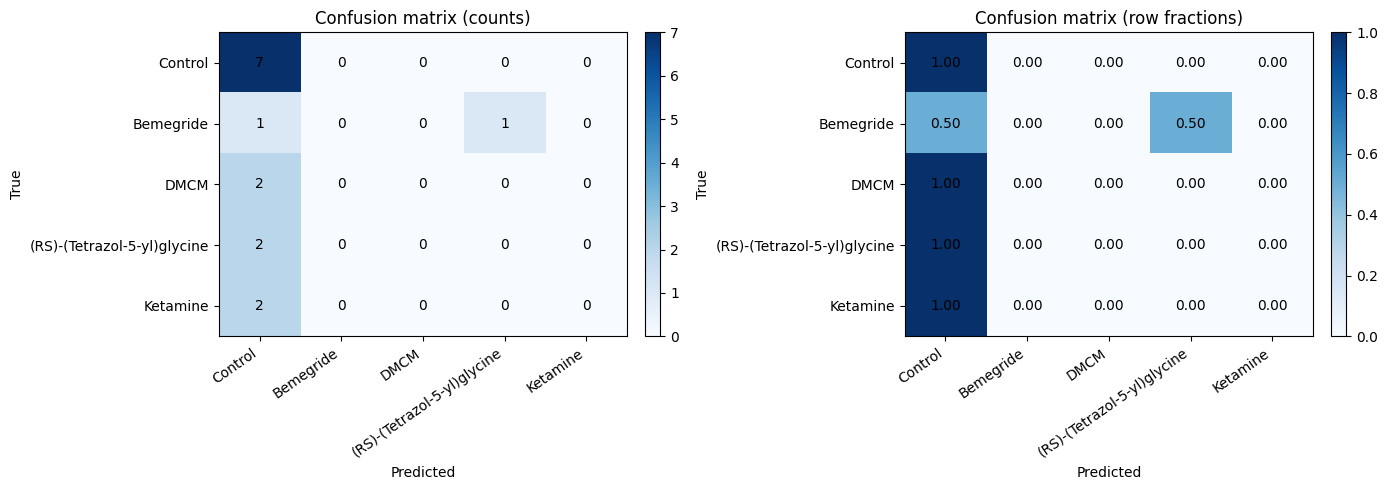


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.666667,0.857143,0.750000,7.0
high,0.833333,0.625000,0.714286,8.0


,value
accuracy,0.733333
macro_precision,0.750000
macro_recall,0.741071
macro_f1,0.732143
weighted_precision,0.755556
weighted_recall,0.733333
weighted_f1,0.730952
n_samples,15.000000
roc_auc,0.767857
average_precision,0.847756


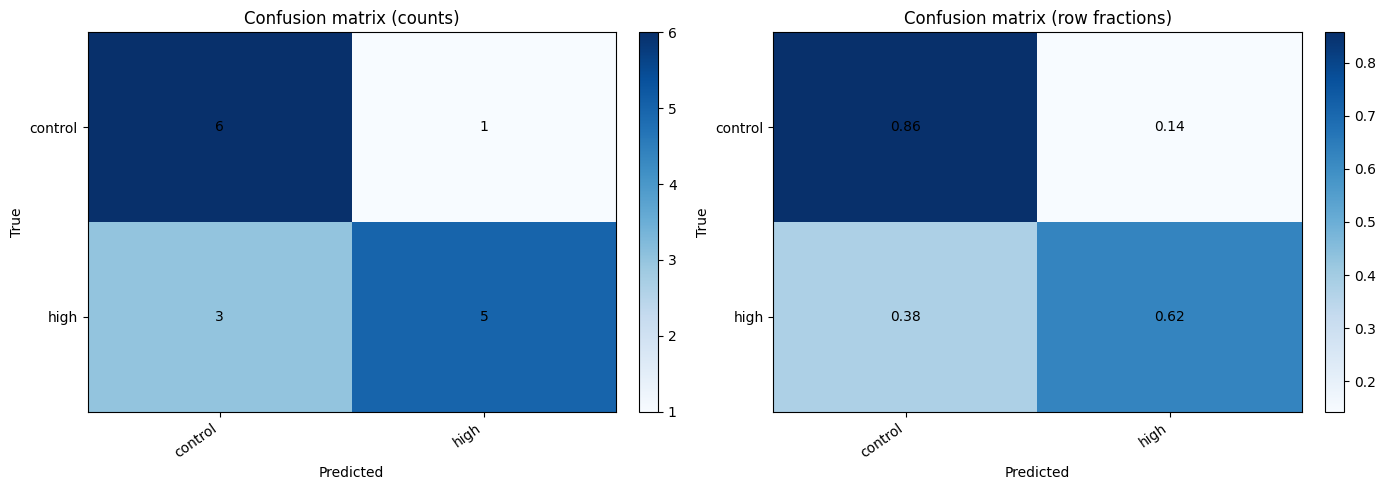

In [32]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

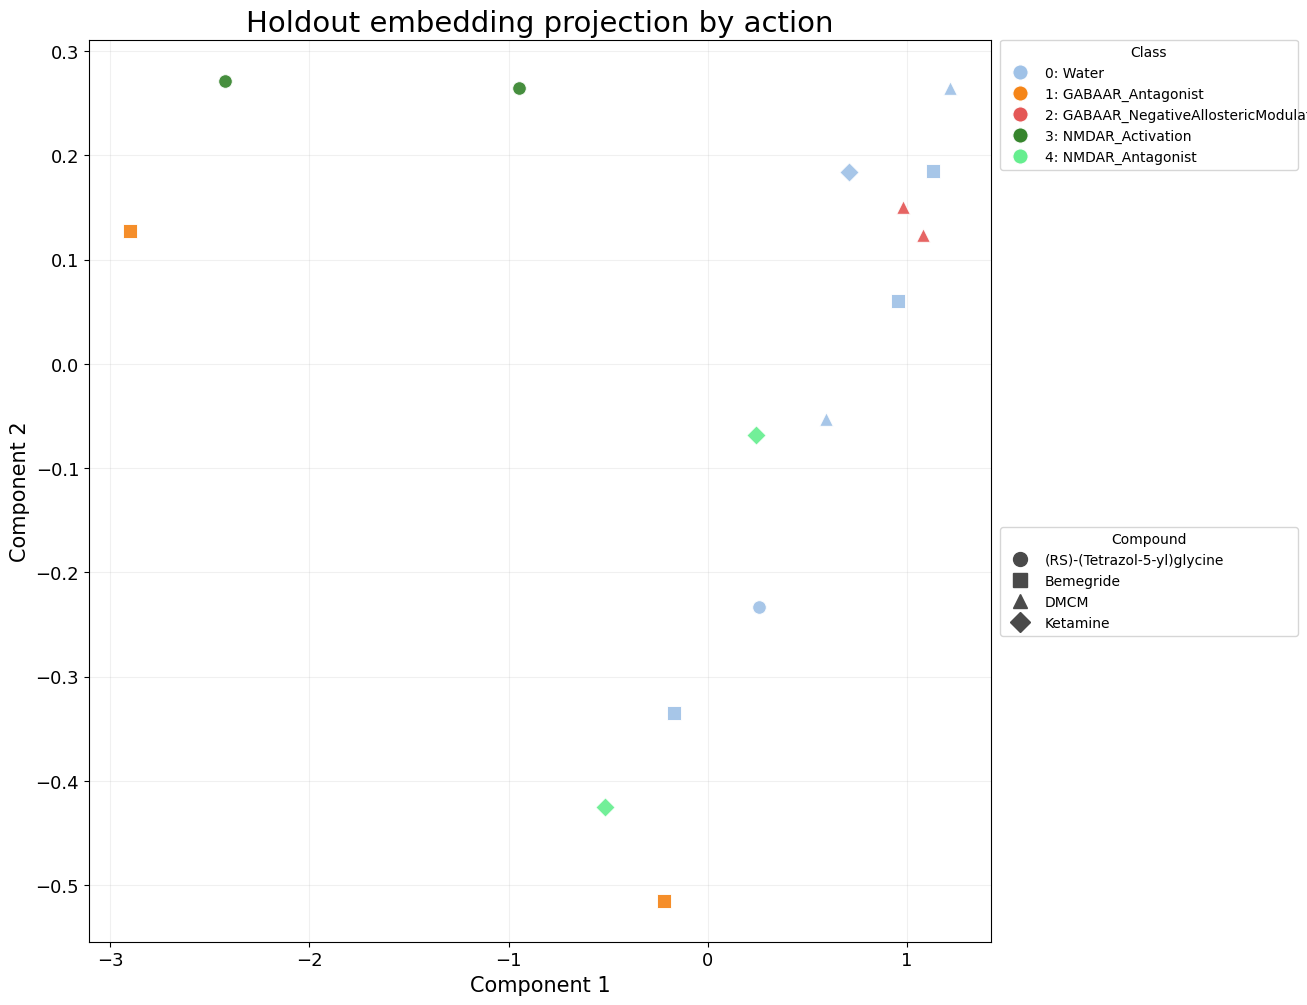

In [33]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="pca",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)


In [34]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}


In [35]:
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
